## Imports

In [306]:
%cd ~/projects/entityrepresentations
!ls

/home/morand/projects/entityrepresentations
EntityRepresentations.ipynb    TaskVec_l20_e60.pth
__pycache__		       TaskVec_pythia-2.8b_l25_e1.pth
README.md		       TaskVec_pythia-2.8b_l25_e44.pth
TaskVec_gpt2-small_l8_e50.pth  utils.py


/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [307]:
import transformer_lens as tl 
from transformer_lens import HookedTransformer, patching
from importlib import reload
import torch, gc
import torch.nn as nn
from tqdm import tqdm
#our own module
import utils 
reload(utils)

<module 'utils' from '/home/morand/projects/entityrepresentations/utils.py'>

In [308]:
gc.collect()
torch.cuda.empty_cache()

## Model Loading

In [4]:
# Load a model (eg GPT-2 Small)
model_name = "bloom-3b" #crashed
model_name = "gpt2-small"
model_name = "gpt2-xl"
model_name = "pythia-2.8b" #ok !
model = HookedTransformer.from_pretrained(model_name)
model.eval()
dim = model.QK.shape[-1]
print(model)

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loaded pretrained model pythia-2.8b into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (h

In [21]:
# print hooks
test_prompt = "The quick brown fox jumped over the lazy dog"
print("Num tokens:", len(model.to_tokens(test_prompt)[0]))
def print_name_shape_hook_function(activation, hook):
    print(hook.name, activation.shape)
not_in_late_block_filter = lambda name: name.startswith("blocks.0.") or not name.startswith("blocks")

model.run_with_hooks(
    test_prompt,
    return_type=None,
    fwd_hooks=[(not_in_late_block_filter, print_name_shape_hook_function)],
)

Num tokens: 10
hook_embed torch.Size([1, 10, 2560])
blocks.0.hook_resid_pre torch.Size([1, 10, 2560])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2560])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2560])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2560])
blocks.0.attn.hook_q torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_k torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_v torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_rot_q torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_rot_k torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_attn_scores torch.Size([1, 32, 10, 10])
blocks.0.attn.hook_pattern torch.Size([1, 32, 10, 10])
blocks.0.attn.hook_z torch.Size([1, 10, 32, 80])
blocks.0.hook_attn_out torch.Size([1, 10, 2560])
blocks.0.ln2.hook_scale torch.Size([1, 10, 1])
blocks.0.ln2.hook_normalized torch.Size([1, 10, 2560])
blocks.0.mlp.hook_pre tor

In [22]:
#test if we get the right hook name
replace_hook_name = tl.utils.get_act_name('embed')
print(replace_hook_name)

hook_embed


## Atomic Tests

In [89]:
prompt, tok = "When Bob and France went to the store, Bob asked"            , 3
prompt, tok = "When Mary and Bob went to the store, Bob asked"              , 3
prompt, tok = "the French Iron King, aka '"                                 , 4
prompt, tok = "Man of steel, commonly known as"                             , 3
prompt, tok = "Alan Bean was an American astronaut, born on March 15, 1932 in Wheeler, Texas. He received a Bachelor of Science degree at the University of \
Texas at Austin in 1955 and was chosen by NASA in 1963. Alan Bean was a"   , 44
prompt, tok = "Alan Bean was an ", 2
prompt, tok = "Barack Obama was an ", 3
prompt, tok = "the molecule HU765DGB introduced herself: 'hi, my name is"   , 7
prompt, tok = "The Eiffel Tower"                                           , 5
prompt, tok = "The Empire State Building is a great monument"               , 4


### Test Generation

In [17]:
res = model.generate(prompt, max_new_tokens=20, temperature=0, return_type="str")
print(res)
# model.to_str_tokens(res)


  0%|          | 0/20 [00:00<?, ?it/s]

The Eiffel Tower 
The Eiffel Tower is a monumental tower in Paris, France, designed by Gustave


### Extract representation at given layer

In [90]:
toks = model.to_str_tokens(prompt)
for i,t  in enumerate(toks): print(i, "\t", t, "  <--" if i==tok else "")

repr = utils.get_representation(model,
                                layer=15,
                                tokens=model.to_tokens(prompt),
                                token_inds=[tok],
                                verbose=True)

0 	 <|endoftext|> 
1 	 The 
2 	  Empire 
3 	  State 
4 	  Building   <--
5 	  is 
6 	  a 
7 	  great 
8 	  monument 
extract representation of tokens [4] at hook blocks.15.hook_resid_post


### Regererate Label from rep
Here we can observe that the last subject's token contain enough information to identify the subject.

In [34]:
utils.generate_from_repr(model, 
                         repr, 
                         retr_prompt="_ is located in the city of", 
                         do_sample=True,)

["<|endoftext|>_ is located in the city of Paris, France. It is the world's tall"]


# Datasets


## WebNLG

### Import

In [309]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset

# Load WebNLG dataset
dataset = load_dataset("web_nlg", "release_v3.0_en")


In [310]:
N_train = len(dataset["train"])
print("training dataset: ",N_train)
print("random sample: ")
item = dataset["train"][np.random.randint(N_train)]
# print(item["text"])
item

training dataset:  13211
random sample: 


{'category': 'Athlete',
 'size': 3,
 'eid': 'Id30',
 'original_triple_sets': {'otriple_set': [['Adam_Maher | team | Netherlands_national_under-17_football_team',
    'Adam_Maher | placeOfBirth | Netherlands',
    'Adam_Maher | clubs | AZ_Alkmaar']]},
 'modified_triple_sets': {'mtriple_set': [['Adam_Maher | club | Netherlands_national_under-17_football_team',
    'Adam_Maher | birthPlace | Netherlands',
    'Adam_Maher | club | AZ_Alkmaar']]},
 'shape': '(X (X) (X) (X))',
 'shape_type': 'sibling',
 'lex': {'comment': ['good', 'good'],
  'lid': ['Id1', 'Id2'],
  'text': ["Adam Maher, whose club is AZ Alkmaar, was born in the Netherlands and played for the country's national under 17 football team.",
   'Netherlands born Adam Maher played for their national under 17 football team and is connected to the AZ Alkmaar club.'],
  'lang': ['', '']},
 'test_category': '',
 'dbpedia_links': [],
 'links': []}

### Build custom Dataset

In [311]:
#optionnal, filter categories from datset
cat = ['Food'] #Cats to remove
cat = None
if cat :
    dataset["train"] = [item for item in dataset["train"] if item["category"] not in cat]
    dataset["test"] = [item for item in dataset["test"] if item["category"] not in cat]

# Create dataset instances
train_dataset = utils.WebNLGDataset(dataset['train'], max_ent_length=40)
test_dataset = utils.WebNLGDataset(dataset['test'])

print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("ex sample:", train_dataset[np.random.randint(len(train_dataset))])

train length: 50710
test length: 15933
ex sample: {'entity': 'El Salvador national football team', 'text': 'Once manager of A D Isidro Metapán, Jorge Humberto Rodriguez, plays for the El Salvador national football team. El Salvador national football team', 'id': 12540}


In [316]:
#print random sample
train_dataset[np.random.randint(N_train)]

{'entity': 'Ab Klink',
 'text': "Ab Klink's place of birth, was Stellendam, in the Netherlands. Ab Klink",
 'id': 11712}

### Augment Dataset with subject representations

In [319]:
layer = 25 #layer where to extract representations
b_size = 30
print("Augmenting Train set with subject representations ... ")
train_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Augmenting Test set with subject representations ... ")
test_dataset.augment_with_repr(model, layer, batch_size=b_size)

print("Extraction of subjects representatons Done !\n")

100%|█████████████████████████████████████████████████████████████████████████████| 508/508 [18:45<00:00,  2.22s/it]


Augmenting Test set with subject representations ... 


 87%|██████████████████████████████████████████████████████████████████▉          | 139/160 [07:50<01:11,  3.39s/it]

In [38]:
print(str(train_dataset[torch.randint(len(train_dataset),(1,))]).replace(", '", ",\n'"))

{'text': 'Construction of 108 St Georges Terrace, Perth, Australia began in 1981. 108 St Georges Terrace',
'entity': '108 St Georges Terrace',
'id': 6391,
'representation': tensor([ 0.8726,  1.1983, -3.2866,  ..., -0.8222, -5.5496,  0.9879]),
'prompt': '_ > 108 St Georges Terrace<|endoftext|>'}


In [10]:
#ex sample from final dataset
test_dataset[67]["entity"]

'Nord (Year of No Light album)'

### Inspect Dataset

In [317]:
import numpy as np
# get the first tokens of all entities
first_tokens = []
for i in range(len(train_dataset)):
    first_tokens.append(model.to_str_tokens(train_dataset[i]["entity"])[1])

# get counts of each token
unique, counts = np.unique(first_tokens, return_counts=True)

# sort by counts
sorted_tokens = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)
sorted_tokens[:30]


[('A', 3572),
 ('United', 2374),
 ('Al', 1774),
 ('B', 1345),
 ('S', 557),
 ('G', 526),
 ('Ab', 499),
 ('C', 475),
 ('New', 471),
 ('J', 458),
 ('M', 451),
 ('R', 430),
 ('D', 426),
 ('English', 424),
 ('K', 415),
 ('F', 387),
 ('Washington', 379),
 ('Ad', 367),
 ('Alan', 354),
 ('L', 317),
 ('Ind', 313),
 ('H', 312),
 ('19', 301),
 ('P', 292),
 ('An', 281),
 ('V', 270),
 ('Ak', 260),
 ('Ale', 260),
 ('16', 258),
 ('It', 253),
 ('Atl', 252),
 ('As', 247),
 ('St', 243),
 ('African', 242),
 ('10', 234),
 ('Ph', 234),
 ('1', 229),
 ('American', 224),
 ('Ap', 224),
 ('T', 220),
 ('John', 214),
 ('Native', 212),
 ('N', 211),
 ('FC', 209),
 ('18', 205),
 ('California', 203),
 ('Asian', 197),
 ('Andrew', 196),
 ('India', 196),
 ('University', 195),
 ('Spain', 180),
 ('U', 179),
 ('I', 170),
 ('O', 170),
 ('s', 166),
 ('11', 165),
 ('And', 164),
 ('Alex', 159),
 ('Texas', 159),
 ('Ar', 158)]

# Training

In [42]:
#utils 
from utils import get_replace_with_rep_hook

def eval_model(model, TaskVec, test_loader, prepend_bos=True):
    """
    Evaluate the model on a given test_loader
    """
    b_count = 0
    m_acc = 0
    replace_hook_name = tl.utils.get_act_name('embed') #pos_embed ?
    rep_idx = 1 if prepend_bos else 0
    taskVec_idx = rep_idx + 1

    with torch.no_grad():
        for batch in tqdm(test_loader):
            b_count += 1
            # print(str(batch).replace("', ", "'\n"))
            prompts = batch["prompt"]
            reps = batch["representation"].squeeze(1)
            b_taskVec = TaskVec.repeat(len(prompts),1)

            tokens = model.to_tokens(prompts, prepend_bos=prepend_bos,)
            inputs = tokens[:,:]
            targets = tokens[:,2:] #don't take the '<eos>','_' ,'called'' tokens into account

            # print(inputs, targets)
            logits = model.run_with_hooks(
                    inputs,
                    return_type = "logits",
                    fwd_hooks=[
                        (replace_hook_name, get_replace_with_rep_hook(reps, rep_idx)), # replace '_' by the subject Representation
                        (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                        ]
                ,)

            # LM Loss and optimization 
            acc = tl.utils.lm_accuracy(logits[:,2:,:], targets) # implementation here
            
            m_acc += acc.item()

    return m_acc / b_count


### Train Label Extraction task vector

In [40]:
dim = model.QK.shape[-1]
prepend_bos = True
# create Task Vector
TaskVec = torch.normal(mean=0, std=1.0, size=(1,dim), requires_grad=True)
losses = []
accs = []
# TaskVec = torch.ones((1,d), requires_grad=True)

for param in model.parameters():
    param.requires_grad = False

Now we train our Taskvector in order to retreive the labels. 
We use the cross entropy loss, *i.e* : $$\ell(x,y)=L=\{l_1,\ldots,l_N\}^\top,\quad l_n=-w_{y_n}\log\frac{\exp(x_{n,y_n})}{\sum_{c=1}^C\exp(x_{n,c})}\cdot1$$
The TransformerLens implementation is [here](https://github.com/TransformerLensOrg/TransformerLens/blob/f4287b68d544b5fe1221739a4f3c2424eccf7d31/transformer_lens/utils.py#L115), **Warning**, it takes as input all the logits, and perform the shift **afterwards** !

In [71]:
#Training params
lr = 1e-2
batch_size = 30
epochs = 2

rep_idx = 1 if prepend_bos else 0 
taskVec_idx = rep_idx + 1
eos_tok = model.tokenizer.eos_token_id
padding_tok = model.tokenizer.eos_token_id
replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=200, shuffle=True)
optim = torch.optim.Adam([TaskVec], lr=lr)
# optim = torch.optim.SGD([TaskVec], lr=lr)
criterion = nn.CrossEntropyLoss()
gc.collect()
torch.cuda.empty_cache()

for epoch in range(epochs):
    b_count = 0
    m_loss = 0
    for batch in tqdm(train_dataloader):
        b_count += 1
        # print(str(batch).replace("', ", "'\n"))
        prompts = batch["prompt"]
        reps = batch["representation"].squeeze(1)
        b_taskVec = TaskVec.repeat(len(prompts),1)

        tokens = model.to_tokens(prompts, prepend_bos=prepend_bos,)
        inputs = tokens[:,:]
        targets = tokens[:,2:] #don't take the '<eos>','_' ,'called'' tokens into account

        # print(inputs, targets)
        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, get_replace_with_rep_hook(reps, rep_idx)), # replace '_' by the subject Representation
                    (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization 
        loss = model.loss_fn(logits[:,2:,:], targets)
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss += loss.item()

    losses.append(m_loss / b_count)
    accs.append(eval_model(model,TaskVec,test_loader=test_dataloader))
    print(f" Epoch {len(losses)}, Language modeling loss: {losses[-1]:.3f}, Test Acc: {accs[-1]:.3f}")
        

100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:30<00:00,  1.54s/it]


 Epoch 45, Language modeling loss: 1.409, Test Acc: 0.762


100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:30<00:00,  1.54s/it]

 Epoch 46, Language modeling loss: 1.383, Test Acc: 0.763


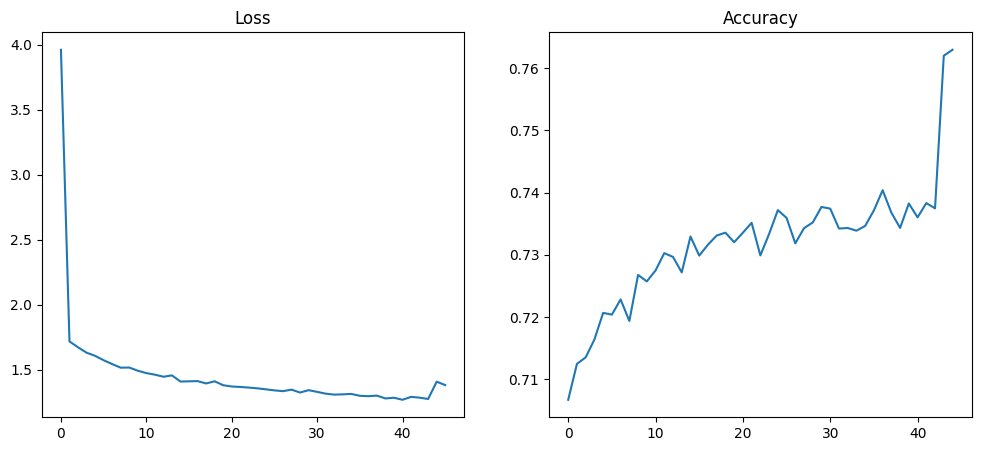

In [72]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(losses)
ax2.plot(accs)
ax1.set_title("Loss")
ax2.set_title("Accuracy")
plt.show()

In [52]:
fileName = f'TaskVec_{model_name}_l{layer}_e{len(losses)}.pth'
torch.save(TaskVec, fileName)

### Testing the model

In [ ]:
TaskVec = torch.load(fileName)

In [73]:
test_dataloader = DataLoader(test_dataset, batch_size=500, shuffle=True)
acc = eval_model(model, TaskVec, test_dataloader)
print(f" Evaluation accuracy on test set: {acc:.3f}")
    

100%|█████████████████████████████████████████████████████████████████████████████████| 8/8 [00:27<00:00,  3.44s/it]

 Evaluation accuracy on test set: 0.766


In [153]:
ind = np.random.randint(len(test_dataset))
print(test_dataset[ind]["text"])
print(test_dataset[ind]["entity"])
s = test_dataset[ind]["representation"].view(1,-1)

# s = repr
utils.generate_from_repr(model, s, TaskVec, retr_prompt="_ >")

Chopped fruits, sour cream, condensed milk, granola, shredded coconut and raisins are the main ingredients in bionico. Bionico (a dessert) is a food found in Mexico. Bionico
Bionico
['<|endoftext|>_ > B<|endoftext|>']
